Download necessary libraries to process the dataset

In [73]:
#!pip install pandas numpy matplotlib scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path #To manage the routes of the data
import gzip #As the data comes in .gz packages
import struct

**Load the Dataset**

In [74]:
DATA_DIR = Path("./data")

X_train_path = DATA_DIR / "train-images-idx3-ubyte.gz"
y_train_path = DATA_DIR / "train-labels-idx1-ubyte.gz"

X_test_path = DATA_DIR / "t10k-images-idx3-ubyte.gz"
y_test_path = DATA_DIR / "t10k-labels-idx1-ubyte.gz"

**Loading the training dataset**

In [75]:
#The features
with gzip.open(X_train_path, "rb") as f:
    #Header
    magic_number = struct.unpack(">I", f.read(4))[0]    #Here is the "magic number" of the file
    num_images = struct.unpack(">I", f.read(4))[0]      #This contains the number of images from the dataset
    num_rows = struct.unpack(">I", f.read(4))[0]        #This is the number of rows per image
    num_columns = struct.unpack(">I", f.read(4))[0]     #This is the number of columns per image

    #Data
    X_train_3d = np.frombuffer(
        f.read(),
        dtype=np.uint8
    )
print("="*20)
print("FEATURES")
print("Magic number:", magic_number)
print("Images:", num_images)
print("Rows:", num_rows)
print("Columns:", num_columns)
print("="*20)

FEATURES
Magic number: 2051
Images: 60000
Rows: 28
Columns: 28


In [76]:
#Reshape the data into a structure
#X_train_3d is an np.ndarray (N-dimensional, Array), in this case it results as a 3d
X_train_3d = X_train_3d.reshape(
    num_images,
    num_rows,
    num_columns
)

#This turns the data into a 3d matrix, selects the number of subsets and assigns to the image each pixel with its gray tone (from 0 for black to 255 for white)

print(X_train_3d.shape)

(60000, 28, 28)


In [77]:
#Turning the features to a 2d matrix to pass it to the model

X_train_2d = X_train_3d.copy().reshape(
    X_train_3d.shape[0],
    -1
)

print(X_train_2d.shape)

(60000, 784)


In [78]:
#The labels
with gzip.open(y_train_path, "rb") as f:
    #Header
    magic_number = struct.unpack(">I", f.read(4))[0]    #Here is the "magic number" of the file
    num_labels = struct.unpack(">I", f.read(4))[0]      #This contains the number of images from the dataset

    #Data - Labels
    y_train_raw = np.frombuffer(
        f.read(),
        dtype=np.uint8
    )

print("="*20)
print("LABELS or TARGET")
print("Magic number:", magic_number)
print("Labels:", num_labels)
print("="*20)

LABELS or TARGET
Magic number: 2049
Labels: 60000


In [79]:
#Reshape the data into a structure
y_train_raw = y_train_raw.reshape(
    num_labels
)

print(y_train_raw.shape)


(60000,)


**Loading the test dataset**

In [80]:
#The features
with gzip.open(X_test_path, "rb") as f:
    #Header
    magic_number = struct.unpack(">I", f.read(4))[0]    #Here is the "magic number" of the file
    num_images = struct.unpack(">I", f.read(4))[0]      #This contains the number of images from the dataset
    num_rows = struct.unpack(">I", f.read(4))[0]        #This is the number of rows per image
    num_columns = struct.unpack(">I", f.read(4))[0]     #This is the number of columns per image

    #Data
    X_test_3d = np.frombuffer(
        f.read(),
        dtype=np.uint8
    )
print("="*20)
print("FEATURES")
print("Magic number:", magic_number)
print("Images:", num_images)
print("Rows:", num_rows)
print("Columns:", num_columns)
print("="*20)

FEATURES
Magic number: 2051
Images: 10000
Rows: 28
Columns: 28


In [81]:
#Reshape the data into a structure
#X_test_3d is an np.ndarray (N-dimensional, Array), in this case it results as a 3d
X_test_3d = X_test_3d.reshape(
    num_images,
    num_rows,
    num_columns
)

#This turns the data into a 3d matrix, selects the number of subsets and assigns to the image each pixel with its gray tone (from 0 for black to 255 for white)

print(X_test_3d.shape)

(10000, 28, 28)


In [82]:
#Turning the features to a 2d matrix to pass it to the model

X_test_2d = X_test_3d.copy().reshape(
    X_test_3d.shape[0],
    -1
)

print(X_test_2d.shape)

(10000, 784)


In [83]:
#The labels
with gzip.open(y_test_path, "rb") as f:
    #Header
    magic_number = struct.unpack(">I", f.read(4))[0]    #Here is the "magic number" of the file
    num_labels = struct.unpack(">I", f.read(4))[0]      #This contains the number of images from the dataset

    #Data - Labels
    y_test_raw = np.frombuffer(
        f.read(),
        dtype=np.uint8
    )

print("="*20)
print("LABELS or TARGET")
print("Magic number:", magic_number)
print("Labels:", num_labels)
print("="*20)

LABELS or TARGET
Magic number: 2049
Labels: 10000


In [84]:
#Reshape the data into a structure
y_test_raw = y_test_raw.reshape(
    num_labels
)

print(y_test_raw.shape)


(10000,)


**Inspecting the data with matplotlib**

In [85]:
#Labels dictionary

labels_dict = {0: "T-shirt/top", 
          1: "Trouser",
          2: "Pullover",
          3: "Dress",
          4: "Coat",
          5: "Sandal",
          6: "Shirt",
          7: "Sneaker",
          8: "Bag",
          9: "Ankle boot"}

Pullover


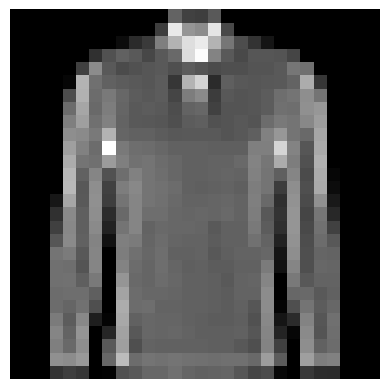

In [86]:
image = 501

print(labels_dict[y_train_raw[image]])
plt.imshow(X_train_3d[image], cmap="gray")
plt.axis("off")
plt.show()


**Feature Engineering**

Creating the data frames

In [87]:
feat_columns = ['pixel' + str(i) for i in range(X_train_2d.shape[1])]  #Create the feature columns (pixels from 0 to 784 -> 28x28)

In [88]:
df_train_fashion_mnist = pd.DataFrame(X_train_2d, columns=feat_columns)

df_train_fashion_mnist['label'] = y_train_raw

print('Size of the dataframe: {}'.format(df_train_fashion_mnist.shape))

print(df_train_fashion_mnist.head())

Size of the dataframe: (60000, 785)
   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       1       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0      33   
4       0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...       114       130        76         0         0         0   
2      22  ...         0         1         0         0         0         0   
3      96  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783 

In [89]:
df_test_fashion_mnist = pd.DataFrame(X_test_2d, columns=feat_columns)

df_test_fashion_mnist['label'] = y_test_raw

print('Size of the dataframe: {}'.format(df_test_fashion_mnist.shape))

print(df_test_fashion_mnist.head())

Size of the dataframe: (10000, 785)
   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       1   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       2       0       1       1       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         3         0         3       174       189        67   
2       0  ...        58         0         0         0         0         0   
3      21  ...         0         0         0         0         0         0   
4       0  ...        12         0         0         0         0         0   

   pixel781  pixel782  pixel783 

**Scale the data**

In [90]:
from sklearn.preprocessing import StandardScaler

In [ ]:
fashion_mnist_scaler = StandardScaler()

X_train = df_train_fashion_mnist.drop("label", axis = 1)
y_train = df_train_fashion_mnist['label']

X_test = df_test_fashion_mnist.drop("label", axis = 1)
y_test = df_test_fashion_mnist['label']

X_train = fashion_mnist_scaler.fit_transform(X_train)
X_test = fashion_mnist_scaler.transform(X_test)